# Load train test data

In [2]:
import joblib

In [3]:
folder_path = '../../data/'
X_train = joblib.load(folder_path + 'x_train.joblib')
y_train = joblib.load(folder_path + 'y_train.joblib')
# X_val = joblib.load(folder_path + 'x_val.joblib')
# y_val = joblib.load(folder_path + 'y_val.joblib')
X_test = joblib.load(folder_path + 'x_test.joblib')
y_test = joblib.load(folder_path + 'y_test.joblib')

In [7]:
X_train.columns

Index(['amount', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER', 'orig_tx_count_same_step', 'orig_tx_cumcount',
       'orig_prev_amount', 'orig_amount_ratio', 'steps_since_last_tx',
       'dest_tx_cumcount', 'dest_prev_amount', 'dest_amount_ratio',
       'dest_steps_since_last', 'pair_tx_cumcount', 'is_new_dest',
       'pair_total_amount', 'hour_of_day', 'day', 'is_night'],
      dtype='object')

# Train model

In [3]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,           # cap depth → prevents memorizing
    min_samples_leaf=10,    # require meaningful leaf size
    max_features='sqrt',    # reduces correlation between trees
    oob_score=True,         # free internal estimate
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)

OOB Score: 0.9418176568252364


In [78]:
y_pred = rf.predict(X_test)

In [79]:
print(y_test.value_counts())

isFraud
0    632498
1      3764
Name: count, dtype: int64


# Test the model

In [85]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score, PrecisionRecallDisplay

In [80]:
fbeta_score(y_test, y_pred, beta=2)

0.486793848429747

In [81]:
print(confusion_matrix(y_test, y_pred))

[[618266  14232]
 [   605   3159]]


In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    632498
           1       0.18      0.84      0.30      3764

    accuracy                           0.98    636262
   macro avg       0.59      0.91      0.64    636262
weighted avg       0.99      0.98      0.98    636262



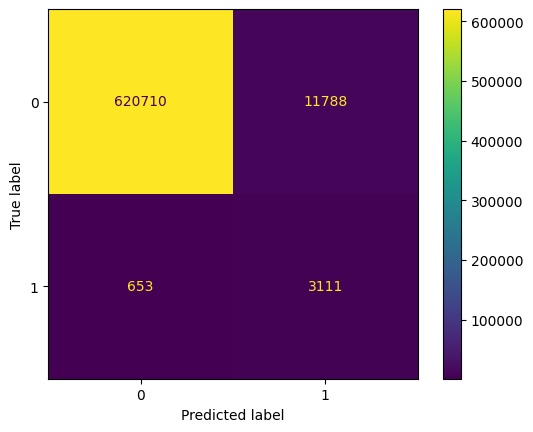

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

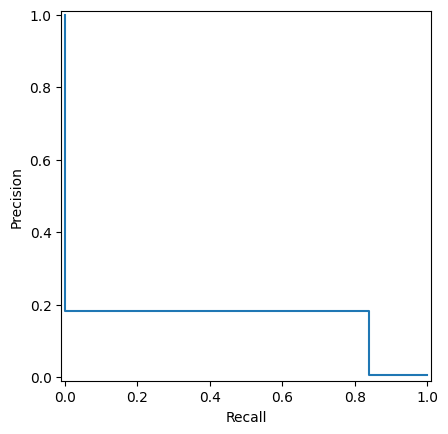

In [90]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()

## Save model

In [92]:
joblib.dump(rf, "../../model/random_forest.joblib")

['../../model/random_forest.joblib']